# Разведочный анализ данных (EDA) — WikiArt

In [4]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Глобальные настройки ---
DATASET_DIR = Path("dataset")
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid", palette="mako")

## 1. Распределение картин по стилям

In [ ]:
# Подсчёт количества изображений в каждой папке-стиле
style_counts = {}
for style_dir in sorted(DATASET_DIR.iterdir()):
    if style_dir.is_dir():
        images = [f for f in style_dir.iterdir()
                  if f.suffix.lower() in {".jpg", ".jpeg", ".png"}]
        style_counts[style_dir.name] = len(images)

df_styles = (
    pd.DataFrame(list(style_counts.items()), columns=["style", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

total = df_styles["count"].sum()
print(f"Всего изображений : {total:,}")
print(f"Количество стилей : {len(df_styles)}")
df_styles.head()


Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_styles, x="count", y="style", palette="mako", ax=ax)


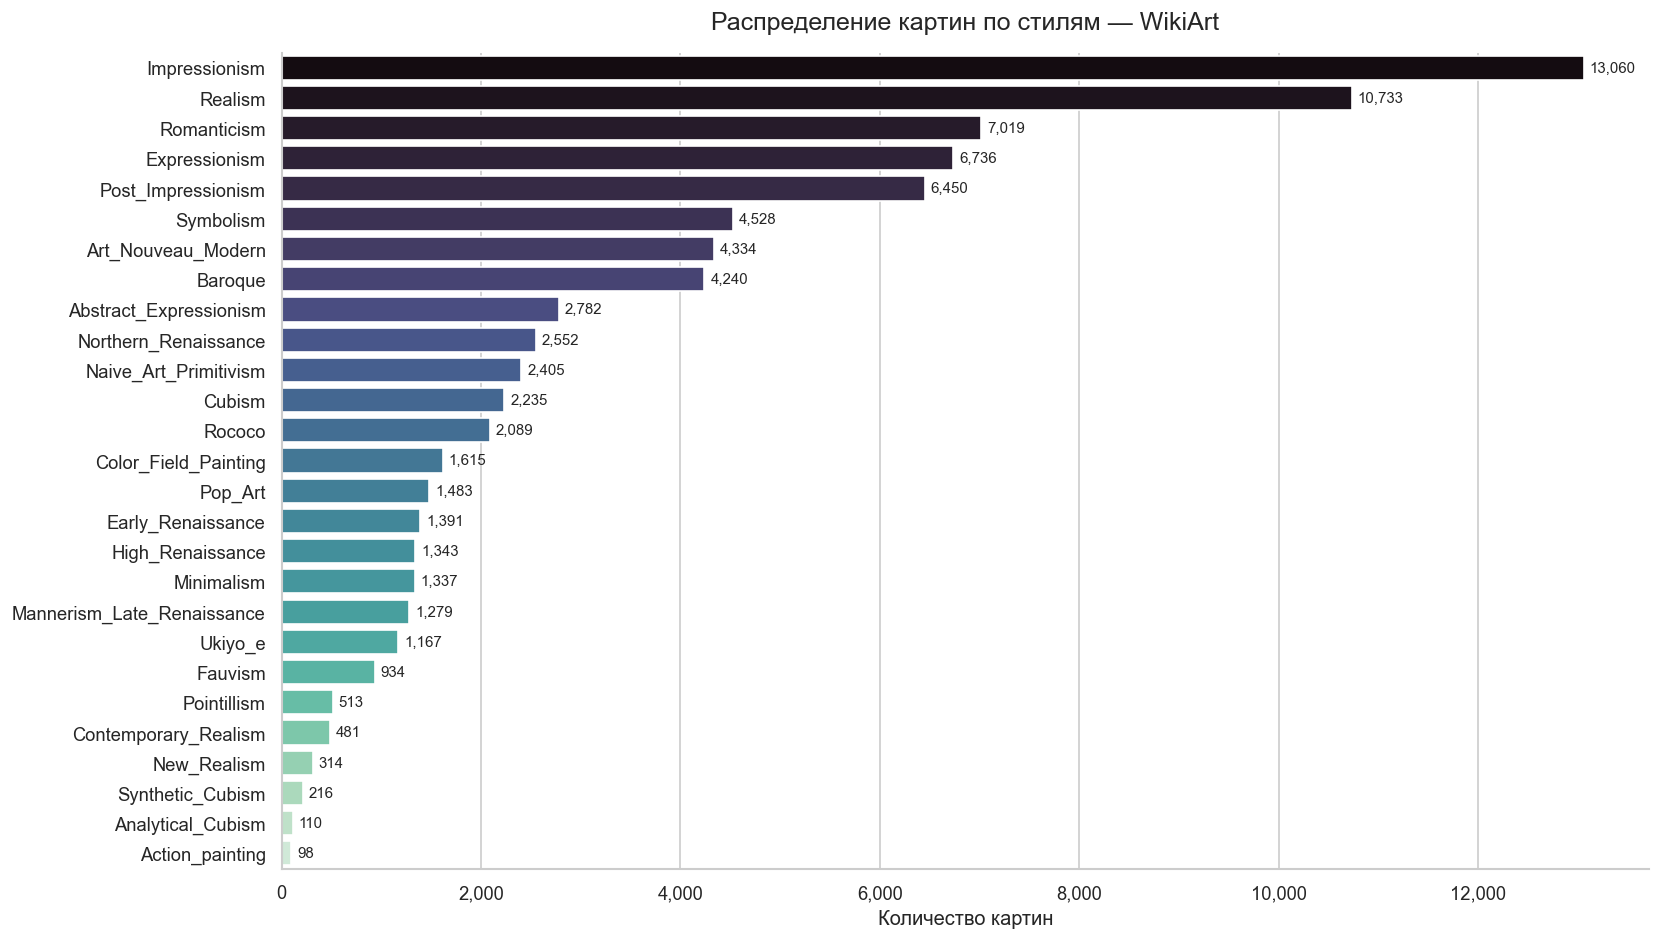

In [ ]:
# Bar chart: стили отсортированы по убыванию количества картин
fig, ax = plt.subplots(figsize=(14, 8))

sns.barplot(data=df_styles, x="count", y="style", palette="mako", ax=ax)

# Подписи значений справа от каждого бара
for bar, val in zip(ax.patches, df_styles["count"]):
    ax.text(
        bar.get_width() + 60,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center", fontsize=9,
    )

ax.set_title("Распределение картин по стилям — WikiArt", fontsize=15, pad=14)
ax.set_xlabel("Количество картин", fontsize=12)
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
sns.despine()
plt.tight_layout()
plt.savefig("eda_style_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Топ-10 стилей: текстовый вывод с долей от общего числа картин
print("Топ-10 стилей по количеству картин:")
print("─" * 48)
for i, row in df_styles.head(10).iterrows():
    pct = row["count"] / total * 100
    print(f"{i+1:>2}. {row['style']:<30} {row['count']:>6,}  ({pct:.1f}%)")
print("─" * 48)
print(f"    {'Итого (топ-10):':<30} {df_styles.head(10)['count'].sum():>6,}  "
      f"({df_styles.head(10)['count'].sum()/total*100:.1f}%)")

Топ-10 стилей по количеству картин:
────────────────────────────────────────────────
 1. Impressionism                  13,060  (16.0%)
 2. Realism                        10,733  (13.2%)
 3. Romanticism                     7,019  (8.6%)
 4. Expressionism                   6,736  (8.3%)
 5. Post_Impressionism              6,450  (7.9%)
 6. Symbolism                       4,528  (5.6%)
 7. Art_Nouveau_Modern              4,334  (5.3%)
 8. Baroque                         4,240  (5.2%)
 9. Abstract_Expressionism          2,782  (3.4%)
10. Northern_Renaissance            2,552  (3.1%)
────────────────────────────────────────────────
    Итого (топ-10):                62,434  (76.7%)


## 2. Примеры изображений

In [ ]:
# Собираем все пути к изображениям вместе с их стилем (нужно для следующих разделов)
all_images = []   # список кортежей (Path, style_name)
for style_dir in sorted(DATASET_DIR.iterdir()):
    if style_dir.is_dir():
        for img_path in sorted(style_dir.iterdir()):
            if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                all_images.append((img_path, style_dir.name))

print(f"Всего изображений найдено: {len(all_images):,}")

Всего изображений найдено: 81,444


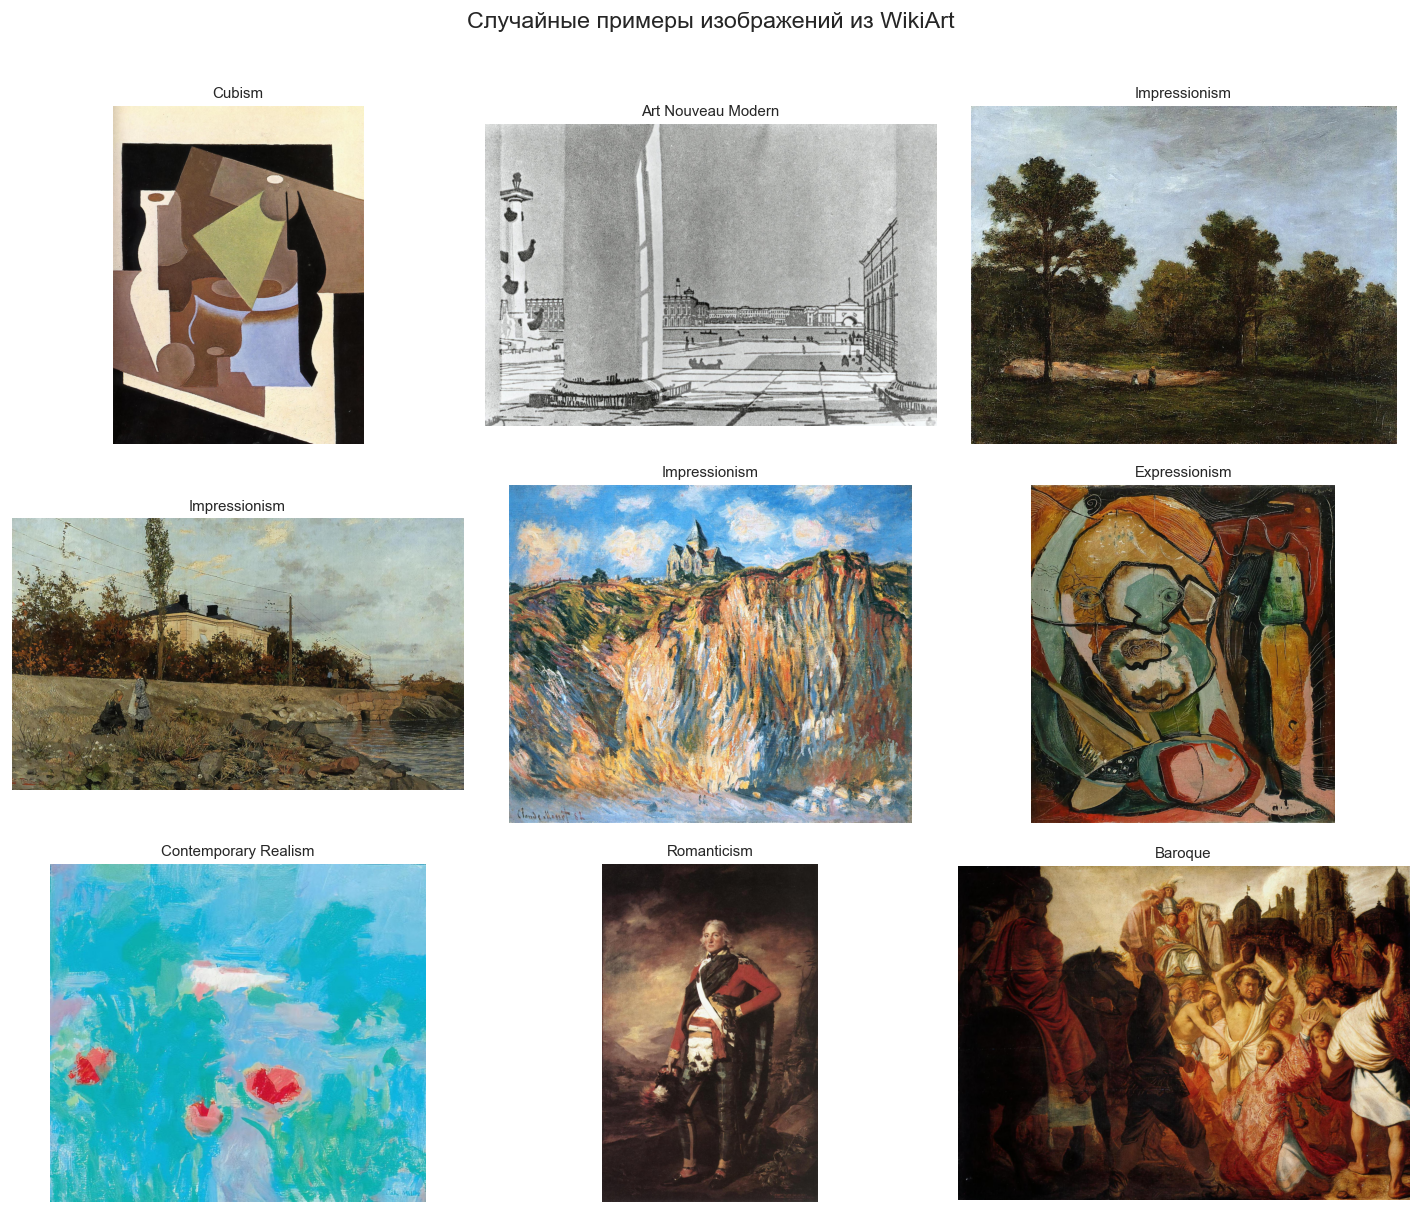

In [ ]:
# Сетка 3×3: случайные примеры из датасета
grid_rows, grid_cols = 3, 3
sample_count = min(len(all_images), grid_rows * grid_cols)
if sample_count == 0:
    raise ValueError("В dataset не найдено ни одного изображения.")
samples = random.sample(all_images, sample_count)

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(12, 10))
fig.suptitle("Случайные примеры изображений из WikiArt", fontsize=14, y=1.01)

for ax in axes.flat[sample_count:]:
    ax.axis("off")

for ax, (img_path, style) in zip(axes.flat, samples):
    with Image.open(img_path) as img:
        ax.imshow(img.convert("RGB"))
    ax.set_title(style.replace("_", " "), fontsize=9, pad=5)
    ax.axis("off")

plt.tight_layout()
plt.savefig("eda_samples.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Анализ размеров изображений

In [ ]:
# Случайная выборка 2500 изображений для анализа размеров
SAMPLE_SIZE = min(2500, len(all_images))
if SAMPLE_SIZE == 0:
    raise ValueError("В dataset не найдено ни одного изображения для анализа размеров.")
sample_paths = random.sample(all_images, SAMPLE_SIZE)

widths, heights, aspects = [], [], []
skipped_size_files = 0

for img_path, _ in sample_paths:
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspects.append(w / h)
    except Exception:
        skipped_size_files += 1
        continue  # пропускаем повреждённые файлы

if not widths:
    raise ValueError("Не удалось прочитать ни одного изображения из выборки.")

print(f"Проанализировано: {len(widths):,} изображений")
if skipped_size_files:
    print(f"Пропущено повреждённых или нечитаемых файлов: {skipped_size_files}")
print(f"Ширина  — мин: {min(widths):,}  макс: {max(widths):,}  среднее: {np.mean(widths):.0f}")
print(f"Высота  — мин: {min(heights):,}  макс: {max(heights):,}  среднее: {np.mean(heights):.0f}")
print(f"Соотношение сторон (W/H) — среднее: {np.mean(aspects):.2f}  медиана: {np.median(aspects):.2f}")

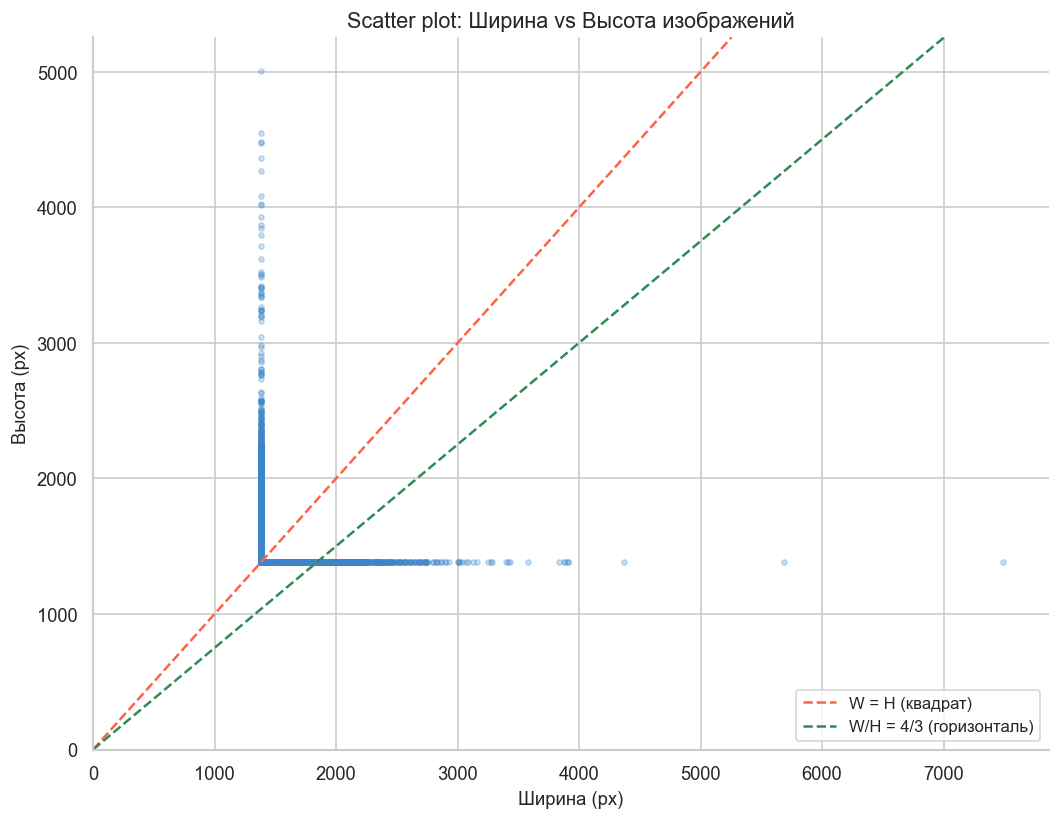

In [ ]:
# Scatter plot: Ширина vs Высота
fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(widths, heights, alpha=0.25, s=10, color="#3d85c8")
ax.axline((0, 0), slope=1, color="tomato", linewidth=1.5, linestyle="--", label="W = H (квадрат)")
ax.axline((0, 0), slope=1/1.333, color="seagreen", linewidth=1.5, linestyle="--", label="W/H = 4/3 (горизонталь)")

ax.set_title("Scatter plot: Ширина vs Высота изображений", fontsize=13)
ax.set_xlabel("Ширина (px)", fontsize=11)
ax.set_ylabel("Высота (px)", fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim(0, max(widths) * 1.05)
ax.set_ylim(0, max(heights) * 1.05)
sns.despine()
plt.tight_layout()
plt.savefig("eda_size_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

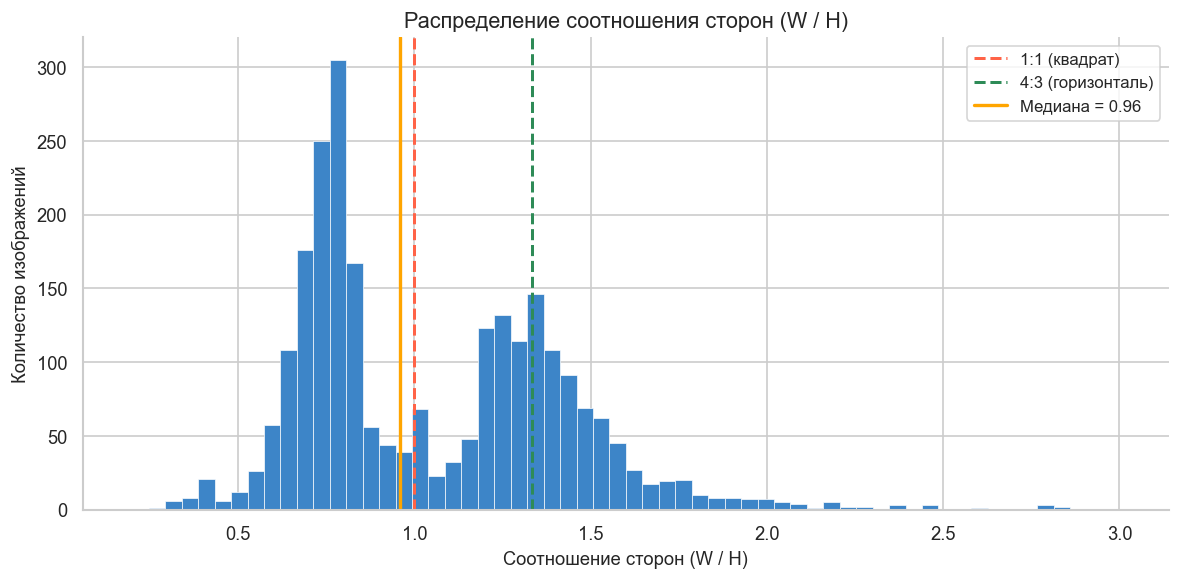

Горизонтальные (W/H > 1.05) :  1143  (45.7%)
Вертикальные   (W/H < 0.95) :  1246  (49.8%)
Квадратные     (≈1:1)       :   111  (4.4%)

Вывод: в выборке почти поровну представлены вертикальные и горизонтальные изображения; квадратные встречаются редко.
Рекомендуемый входной размер для CNN: 224×224 или 256×256 (со сжатием).


In [ ]:
# Гистограмма соотношения сторон (W/H)
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(aspects, bins=60, range=(0.2, 3.0), color="#3d85c8", edgecolor="white", linewidth=0.4)
ax.axvline(1.0, color="tomato",   linestyle="--", linewidth=1.8, label="1:1 (квадрат)")
ax.axvline(1.333, color="seagreen", linestyle="--", linewidth=1.8, label="4:3 (горизонталь)")
ax.axvline(np.median(aspects), color="orange", linestyle="-",  linewidth=2,   label=f"Медиана = {np.median(aspects):.2f}")

ax.set_title("Распределение соотношения сторон (W / H)", fontsize=13)
ax.set_xlabel("Соотношение сторон (W / H)", fontsize=11)
ax.set_ylabel("Количество изображений", fontsize=11)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig("eda_aspect_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Текстовый вывод ---
landscape = sum(1 for a in aspects if a > 1.05)
portrait  = sum(1 for a in aspects if a < 0.95)
square    = sum(1 for a in aspects if 0.95 <= a <= 1.05)
n = len(aspects)
print(f"Горизонтальные (W/H > 1.05) : {landscape:>5}  ({landscape/n*100:.1f}%)")
print(f"Вертикальные   (W/H < 0.95) : {portrait:>5}  ({portrait/n*100:.1f}%)")
print(f"Квадратные     (≈1:1)       : {square:>5}  ({square/n*100:.1f}%)")
print()
print("Вывод: в выборке почти поровну представлены вертикальные и горизонтальные изображения; квадратные встречаются редко.")
print("Рекомендуемый входной размер для CNN: 224×224 или 256×256 (со сжатием).")

## 4. Анализ разбиения train / val / test

In [ ]:
# Загружаем метаданные и смотрим на колонку subset
df_meta = pd.read_csv(DATASET_DIR / "classes.csv")

print(f"Строк в classes.csv: {len(df_meta):,}")
print(f"Колонки: {list(df_meta.columns)}\n")
df_meta.head(3)

Строк в classes.csv: 80,042
Колонки: ['filename', 'artist', 'genre', 'description', 'phash', 'width', 'height', 'genre_count', 'subset']



,filename,artist,genre,description,phash,width,height,genre_count,subset
0,Abstract_Expressionism/aaron-siskind_acolman-1...,aaron siskind,['Abstract Expressionism'],acolman-1-1955,bebbeb018a7d80a8,1922,1382,1,train
1,Abstract_Expressionism/aaron-siskind_chicago-6...,aaron siskind,['Abstract Expressionism'],chicago-6-1961,d7d0781be51fc00e,1382,1746,1,train
2,Abstract_Expressionism/aaron-siskind_glouceste...,aaron siskind,['Abstract Expressionism'],gloucester-16a-1944,9f846e5a6c639325,1382,1857,1,train


In [ ]:
# Общее разбиение по subset
split_total = df_meta["subset"].value_counts().rename_axis("subset").reset_index(name="count")
split_total["pct"] = split_total["count"] / split_total["count"].sum() * 100
print("Общее разбиение:")
print(split_total.to_string(index=False))
print()

Общее разбиение:
          subset  count       pct
           train  63998 79.955523
            test  16000 19.989506
uncertain artist     44  0.054971



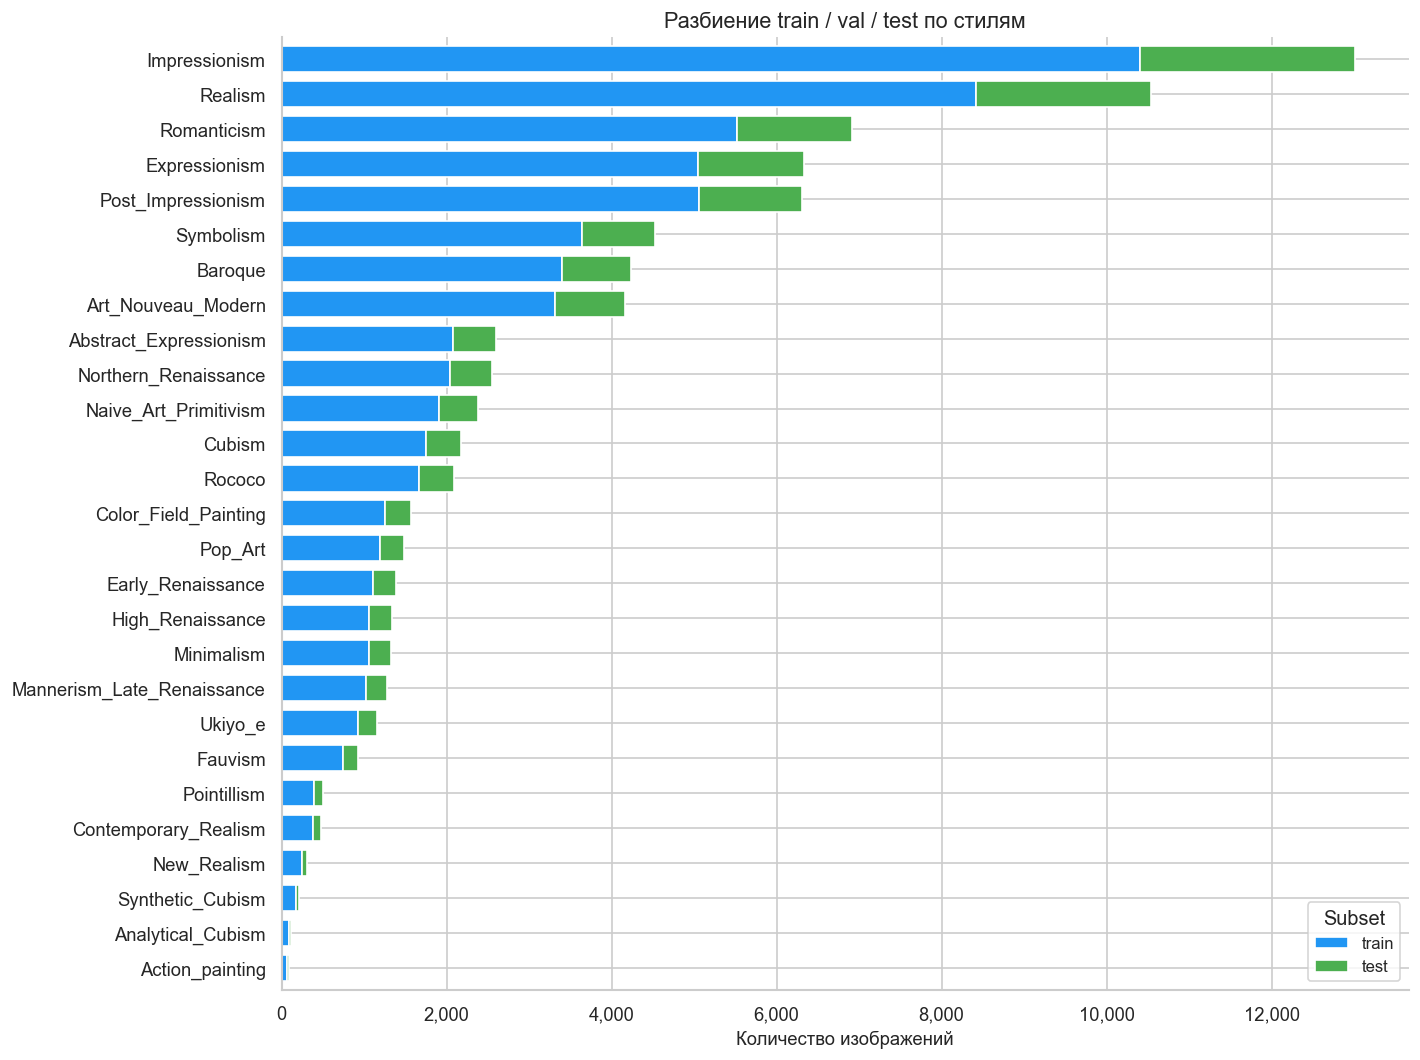

In [ ]:
# Разбиение по каждому стилю: stacked bar chart
df_split = (
    df_meta.assign(style=df_meta["filename"].str.split("/").str[0])
    .groupby(["style", "subset"])
    .size()
    .unstack(fill_value=0)
)
# Сортируем по общему числу
df_split = df_split.loc[df_split.sum(axis=1).sort_values(ascending=True).index]

colors = {"train": "#2196F3", "val": "#FF9800", "test": "#4CAF50"}
present = [c for c in ["train", "val", "test"] if c in df_split.columns]

fig, ax = plt.subplots(figsize=(12, 9))
df_split[present].plot(kind="barh", stacked=True, ax=ax,
                        color=[colors[c] for c in present], width=0.75)

ax.set_title("Разбиение train / val / test по стилям", fontsize=13)
ax.set_xlabel("Количество изображений", fontsize=11)
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title="Subset", fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig("eda_split.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Цветовой анализ

In [ ]:
# Для каждого из топ-10 стилей вычисляем среднее RGB по 200 случайным картинам
STYLES_FOR_COLOR = df_styles.head(10)["style"].tolist()
SAMPLE_PER_STYLE = 200

mean_colors = {}   # style -> (R, G, B) int
skipped_color_files = 0

for style in STYLES_FOR_COLOR:
    style_dir = DATASET_DIR / style
    imgs = [p for p in sorted(style_dir.iterdir()) if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
    sample = random.sample(imgs, min(SAMPLE_PER_STYLE, len(imgs)))

    r_acc, g_acc, b_acc = [], [], []
    for img_path in sample:
        try:
            with Image.open(img_path) as img:
                # Уменьшаем до 64x64 для скорости
                arr = np.array(img.convert("RGB").resize((64, 64)), dtype=np.float32)
                r_acc.append(arr[:, :, 0].mean())
                g_acc.append(arr[:, :, 1].mean())
                b_acc.append(arr[:, :, 2].mean())
        except Exception:
            skipped_color_files += 1
            continue

    if not r_acc:
        print(f"{style:<30}  пропущен: не удалось прочитать ни одного изображения")
        continue

    mean_colors[style] = (int(np.mean(r_acc)), int(np.mean(g_acc)), int(np.mean(b_acc)))
    r, g, b = mean_colors[style]
    print(f"{style:<30}  RGB({r:>3}, {g:>3}, {b:>3})")

print("\nГотово.")
if skipped_color_files:
    print(f"Пропущено повреждённых или нечитаемых файлов: {skipped_color_files}")

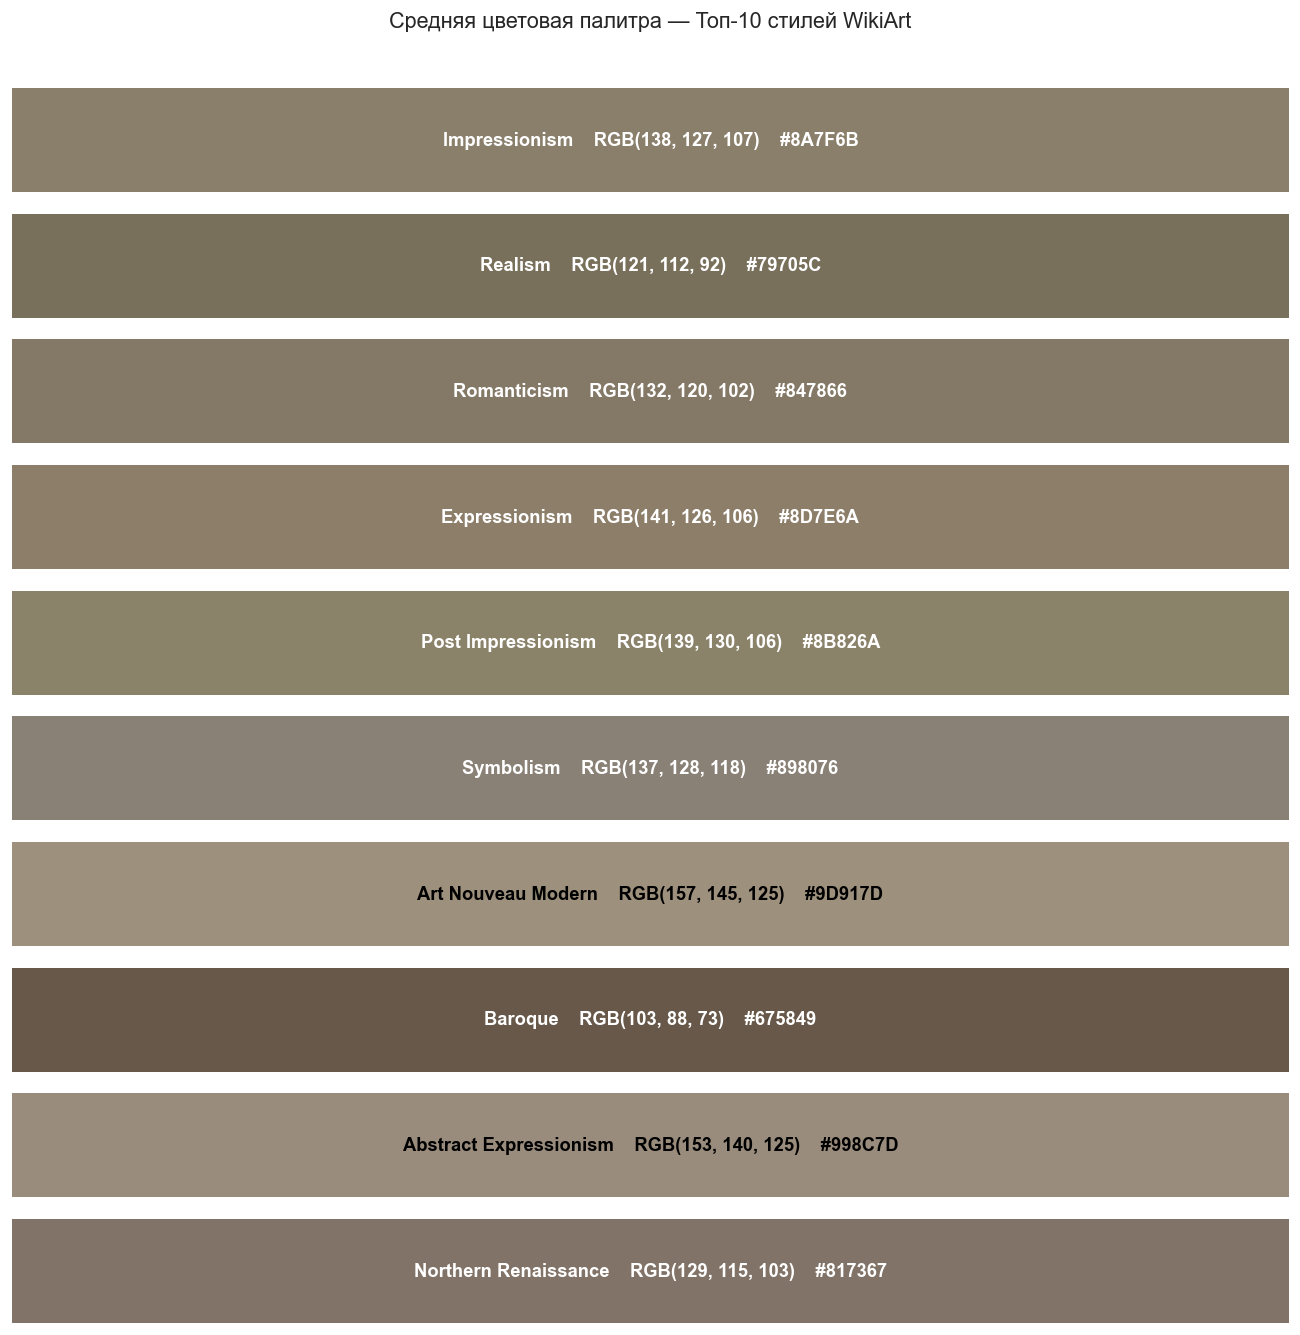

In [ ]:
# Визуализация: цветовые полосы для каждого стиля
if not mean_colors:
    raise ValueError("Не удалось вычислить средние цвета ни для одного стиля.")

fig, axes = plt.subplots(len(mean_colors), 1, figsize=(11, len(mean_colors) * 1.1))
if len(mean_colors) == 1:
    axes = [axes]
fig.suptitle("Средняя цветовая палитра — Топ-10 стилей WikiArt", fontsize=13, y=1.01)

for ax, (style, (r, g, b)) in zip(axes, mean_colors.items()):
    norm_color = (r / 255, g / 255, b / 255)
    ax.set_facecolor(norm_color)

    # Определяем цвет текста по яркости фона (формула luminance)
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    text_color = "white" if luminance < 140 else "black"

    hex_color = f"#{r:02X}{g:02X}{b:02X}"
    label = f"{style.replace('_', ' ')}    RGB({r}, {g}, {b})    {hex_color}"
    ax.text(0.5, 0.5, label, transform=ax.transAxes,
            ha="center", va="center", fontsize=11,
            color=text_color, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig("eda_color_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Подготовка данных для обучения (Data Splitting)

In [ ]:
import shutil
from tqdm import tqdm

# --- Параметры ---
TOP_N = 10
OUTPUT_DIR = Path("dataset_top10")
VALID_IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}

top10_styles = df_styles.head(TOP_N)["style"].tolist()

df_top_meta = (
    df_meta.assign(
        style=df_meta["filename"].str.split("/").str[0],
        rel_path=df_meta["filename"].map(Path),
    )
    .loc[lambda df: df["style"].isin(top10_styles)]
    .copy()
)

available_subsets = [subset for subset in ("train", "val", "test") if subset in set(df_top_meta["subset"])]

if not available_subsets:
    raise ValueError("В classes.csv не найдены подмножества train/val/test для выбранных стилей.")

print("Топ-10 стилей для обучения:")
for i, style in enumerate(top10_styles, 1):
    print(f"  {i:>2}. {style}")

print(f"\nБудут использованы официальные subset из classes.csv: {', '.join(available_subsets)}")

In [ ]:
# Пересобираем dataset_top10 с нуля, чтобы не оставлять файлы от прошлых запусков
for subset in available_subsets:
    subset_dir = OUTPUT_DIR / subset
    if subset_dir.exists():
        shutil.rmtree(subset_dir)

for subset in available_subsets:
    for style in top10_styles:
        (OUTPUT_DIR / subset / style).mkdir(parents=True, exist_ok=True)

print(f"Папки пересозданы в: {OUTPUT_DIR.resolve()}")

In [ ]:
# Копируем изображения в официальные train / val / test по metadata с прогресс-баром
results = []
missing_files = []

for style in tqdm(top10_styles, desc="Стили", unit="стиль"):
    style_rows = df_top_meta.loc[df_top_meta["style"] == style].copy()
    style_rows = style_rows.loc[
        style_rows["rel_path"].map(lambda path: path.suffix.lower()).isin(VALID_IMAGE_SUFFIXES)
    ]

    style_result = {"style": style, "total": 0, "missing": 0}
    for subset in available_subsets:
        style_result[subset] = 0
        subset_rows = style_rows.loc[style_rows["subset"] == subset]

        for rel_path in tqdm(subset_rows["rel_path"], desc=f"  {subset}/{style}", leave=False, unit="img"):
            src_path = DATASET_DIR / rel_path
            if not src_path.exists():
                missing_files.append(str(src_path))
                style_result["missing"] += 1
                continue

            relative_inside_style = Path(*rel_path.parts[1:]) if len(rel_path.parts) > 1 else Path(rel_path.name)
            dst_path = OUTPUT_DIR / subset / style / relative_inside_style
            dst_path.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src_path, dst_path)

            style_result[subset] += 1
            style_result["total"] += 1

    results.append(style_result)

print("Копирование завершено.")
if missing_files:
    print(f"Не найдены {len(missing_files)} файлов. Первые примеры:")
    for path in missing_files[:5]:
        print(f"  - {path}")

In [ ]:
# Итоговая таблица количества файлов по классам
if not results:
    raise ValueError("Список results пуст. Сначала выполните ячейку копирования изображений.")

df_split_result = pd.DataFrame(results).sort_values("total", ascending=False).reset_index(drop=True)

for subset in available_subsets:
    df_split_result[f"{subset}_%"] = (
        df_split_result[subset] / df_split_result["total"] * 100
    ).round(1)

totals = {
    "style": "ИТОГО",
    "total": int(df_split_result["total"].sum()),
    "missing": int(df_split_result["missing"].sum()),
}
for subset in available_subsets:
    totals[subset] = int(df_split_result[subset].sum())
    totals[f"{subset}_%"] = round(totals[subset] / totals["total"] * 100, 1) if totals["total"] else 0.0

df_display = pd.concat([df_split_result, pd.DataFrame([totals])], ignore_index=True)
print(f"Датасет сохранён в: {OUTPUT_DIR.resolve()}")
print(f"Всего скопировано файлов: {totals['total']}")
if totals["missing"]:
    print(f"Файлов не найдено: {totals['missing']}")

df_display

## 4. Архивация датасета для Google Colab

In [8]:
# Архивируем dataset_top10 в dataset_top10.zip в корне проекта
archive_path = shutil.make_archive(
    base_name=str(Path("dataset_top10")),  # имя архива (без расширения)
    format="zip",
    root_dir=".",
    base_dir="dataset_top10",
)

# Проверяем размер архива
size_mb = Path(archive_path).stat().st_size / (1024 * 1024)
print(f"Архив готов! Размер: {size_mb:.1f} MB")

Архив готов! Размер: 30057.3 MB
